In [ ]:
!pip -q install librosa==0.10.2.post1 noisereduce==3.0.2 soundfile==0.12.1 scipy==1.14.1 matplotlib==3.8.4
# (Usually preinstalled, but this helps librosa handle mp3/ogg too)
!apt -q install -y ffmpeg > /dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 22.0 MB/s eta 0:00:00




In [ ]:
from google.colab import files
up = files.upload()  # Choose a file from your computer
fname = list(up.keys())[0]
fname

Saving Pacific Hills Lutheran Church-Lcms.m4a to Pacific Hills Lutheran Church-Lcms.m4a


'Pacific Hills Lutheran Church-Lcms.m4a'

In [ ]:
import numpy as np
import librosa, noisereduce as nr
from scipy.signal import wiener

def load_audio(path, sr=None, mono=True):
    y, sr = librosa.load(path, sr=sr, mono=mono)
    return y, sr

def spectral_gate(y, sr, noise_clip=None, prop_decrease=1.0):
    return nr.reduce_noise(y=y, sr=sr, y_noise=noise_clip, prop_decrease=prop_decrease)

def wiener_1d(y, kernel=5):
    return wiener(y, mysize=kernel)

In [ ]:
import matplotlib.pyplot as plt
import librosa.display as ldisplay

def stft_db(y, sr, n_fft=1024, hop=None, win=None):
    hop = hop or (n_fft//4)
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win, window='hann', center=True)
    S = np.abs(D)
    return librosa.amplitude_to_db(S, ref=np.max), hop

def mel_db(y, sr, n_mels=128, n_fft=1024, hop=None, fmin=0.0, fmax=None):
    hop = hop or (n_fft//4)
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft,
                                       hop_length=hop, fmin=fmin, fmax=fmax)
    return librosa.power_to_db(M, ref=np.max), hop

def show_before_after_specs(y_in, y_out, sr, kind="stft", n_fft=1024, hop=None, n_mels=128):
    if kind=="mel":
        S_in, hop = mel_db(y_in, sr, n_mels=n_mels, n_fft=n_fft, hop=hop)
        S_out, _   = mel_db(y_out, sr, n_mels=n_mels, n_fft=n_fft, hop=hop)
        y_axis="mel"
    else:
        S_in, hop = stft_db(y_in, sr, n_fft=n_fft, hop=hop)
        S_out,_   = stft_db(y_out, sr, n_fft=n_fft, hop=hop)
        y_axis="linear"

    fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    ldisplay.specshow(S_in,  sr=sr, hop_length=hop, x_axis="time", y_axis=y_axis, ax=axes[0])
    axes[0].set_title("Before (dB)")
    im = ldisplay.specshow(S_out, sr=sr, hop_length=hop, x_axis="time", y_axis=y_axis, ax=axes[1])
    axes[1].set_title("After (dB)")
    ##fig.colorbar(im, ax=axes, format="%+2.0f dB")
    fig.tight_layout()
    plt.show()

/tmp/ipython-input-740640764.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=sr, mono=mono)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Before (original):


After (denoised):


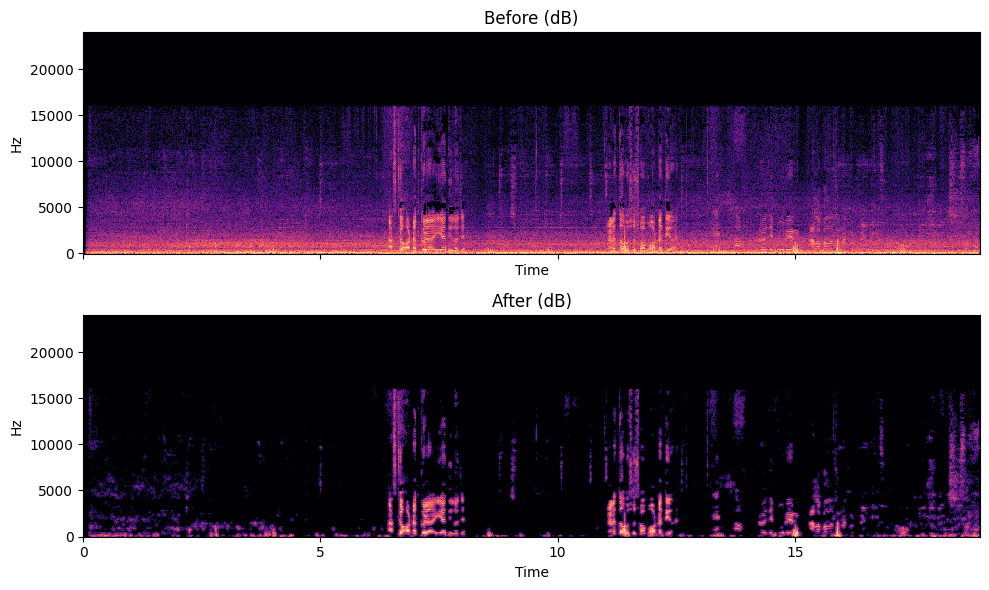

In [ ]:
from IPython.display import Audio, display

# Load
y, sr = load_audio(fname, sr=None, mono=True)

# (Optional) use first 0.5 s as noise profile for spectral gating
noise_sec = 0.5
noise_clip = y[:int(noise_sec*sr)]

# Choose an algorithm: "sgate" or "wiener"
algo = "sgate"        # <- change to "wiener" to try the other method
prop_decrease = 1.0   # 0..1 (1 = stronger reduction). Used by spectral gate.

if algo == "sgate":
    y_hat = spectral_gate(y, sr, noise_clip=noise_clip, prop_decrease=prop_decrease)
else:
    y_hat = wiener_1d(y, kernel=5)

# --- AUDIO: play before/after right in the notebook
print("Before (original):")
display(Audio(y, rate=sr))     # inline audio widget
print("After (denoised):")
display(Audio(y_hat, rate=sr))

# --- SPECTROGRAMS: displayed inline (no files saved)
show_before_after_specs(y, y_hat, sr, kind="stft", n_fft=1024, hop=256)  # or kind="mel"